In [1]:
import numpy as np
import pickle
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from statsmodels.stats.stattools import durbin_watson

In [3]:
with open('all_variables.pkl', 'rb') as f:
    r2_df = pickle.load(f)

In [4]:
import nibabel as nb

In [8]:
ts_files = glob('/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/timeseries/xcpd/sub-*/*ses-1*ptseries.nii')

In [9]:
sub_list = []
_ = [sub_list.append(ii.split('/')[-2]) for ii in ts_files]

In [10]:
cifti = nb.load(ts_files[1])
cifti_data = cifti.get_fdata(dtype=np.float32)

In [11]:
dw_df = pd.DataFrame(index=sub_list, columns=range(1,100)) 
for file in ts_files: 
    sub_id = file.split('/')[-2]
    cifti = nb.load(file).get_fdata(dtype=np.float32)
    for ii in range(0,100): 
        dw_df.loc[sub_id, ii] = (durbin_watson(cifti[:,ii], axis=0)) 

In [12]:
dw_df.to_csv('xcpddw_df.csv') 

In [13]:
dw_df.mean().sort_values(ascending=False)[:20]

10    0.049299
59    0.047791
24    0.047461
58    0.047347
41    0.047273
5     0.047203
55    0.047202
36    0.047072
62    0.047052
9     0.046972
50    0.046911
93    0.046828
86    0.046818
0     0.046742
12    0.046682
61     0.04647
31    0.046196
2     0.046052
27    0.045998
11    0.045896
dtype: object

In [1]:
plt.plot(cifti[:,29]) 
plt.plot(cifti[:,1]) 

NameError: name 'plt' is not defined

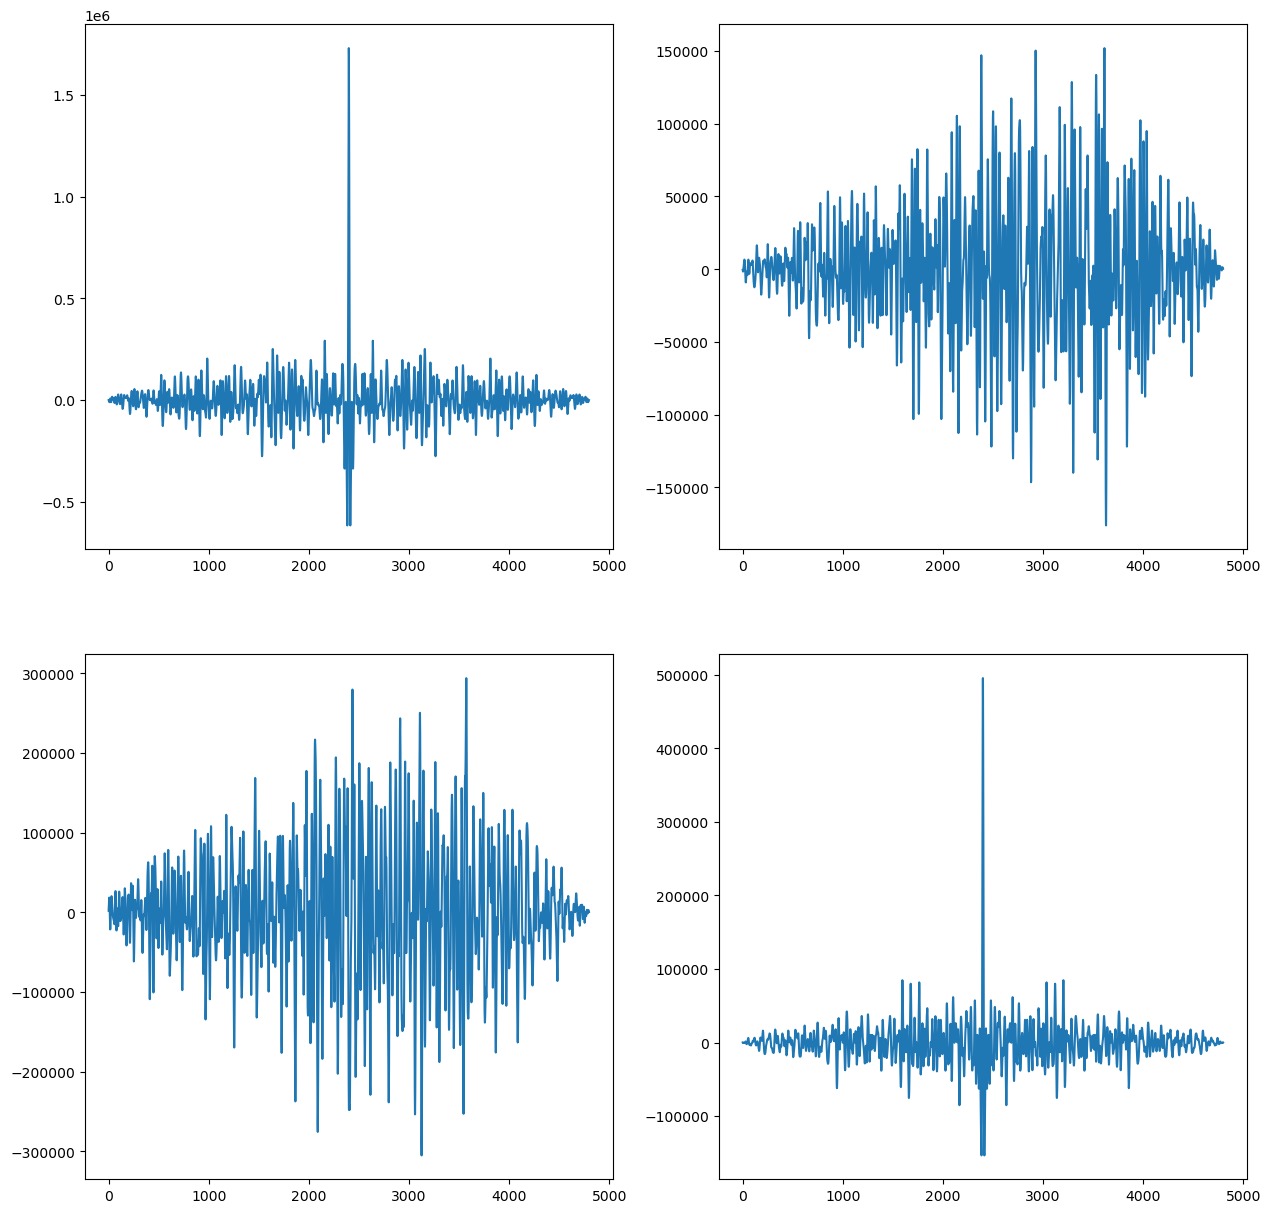

In [24]:
fig, ax = plt.subplots(2,2, figsize=(15,15) ) 
ax[0,0].plot(np.correlate(cifti[:,1], cifti[:,1], mode='full' )) 
ax[0,1].plot(np.correlate(cifti[:,1], cifti[:,30], mode='full'))
ax[1,1].plot(np.correlate(cifti[:,30], cifti[:,30], mode='full' )) 
ax[1,0].plot(np.correlate(cifti[:,1], cifti[:,65], mode='full' )) 

#add another good time series 

#normalize by norm of vector

In [ ]:
dw_df.mean()[76]

(array([-2399, -2398, -2397, ...,  2397,  2398,  2399], shape=(4799,)),
 array([0.00043064, 0.00068951, 0.00071499, ..., 0.00071499, 0.00068951,
        0.00043064], shape=(4799,), dtype=float32),
 <matplotlib.lines.Line2D at 0x7fd69cec9e50>)

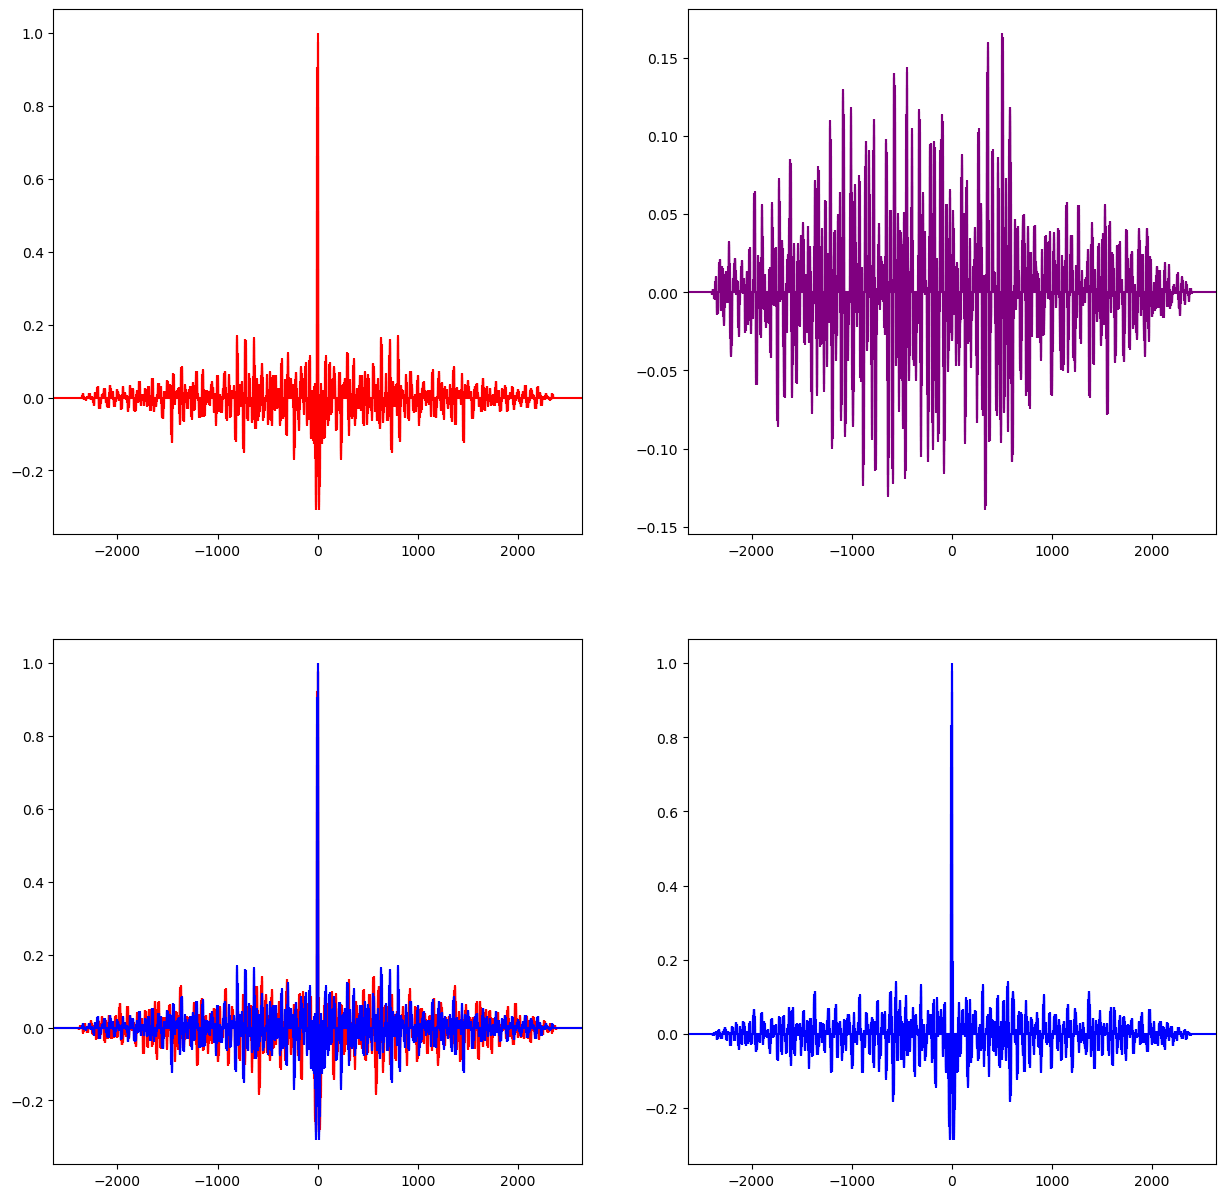

In [34]:
fig, ax = plt.subplots(2,2, figsize=(15,15) ) 

ax[0,0].xcorr(cifti[:,30], cifti[:,30], color='red', maxlags=2399) 
ax[1,1].xcorr(cifti[:,70], cifti[:,70],   color='blue', maxlags=2399) 

ax[0,1].xcorr(cifti[:,30], cifti[:,70], color='purple', maxlags=2399) 
ax[1,0].xcorr(cifti[:,70], cifti[:,70], color='red', maxlags=2399) 
ax[1,0].xcorr(cifti[:,30], cifti[:,30], color='blue', maxlags=2399) 


In [ ]:
dw_df.describe()